In [2]:
%load_ext autoreload
%autoreload 2
from atelier_cours.cnns_demo.arcade_dataset import ArcadeDataset
from unet import UNet
from pathlib import Path
from tqdm.auto import tqdm
from torch.utils.data import DataLoader
import torch
from monai.losses import DiceLoss
import torch.nn as nn
from utils import compute_and_plot_confusion_matrix


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
root_data = Path("C:/Users/cleme/OneDrive/PostDoc/data/arcade/syntax/")
train_dataset  = ArcadeDataset(root_data / "train", resolution=(64, 64))
val_dataset  = ArcadeDataset(root_data / "val", resolution=(64, 64))
test_dataset  = ArcadeDataset(root_data / "test", resolution=(64, 64))

In [4]:
unet = UNet(in_channels=1, out_channels=1).cuda()
train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_dataloader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=8, shuffle=False)

Epoch 1/10 - Training:   0%|          | 0/125 [00:06<?, ?it/s]

Epoch 1/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

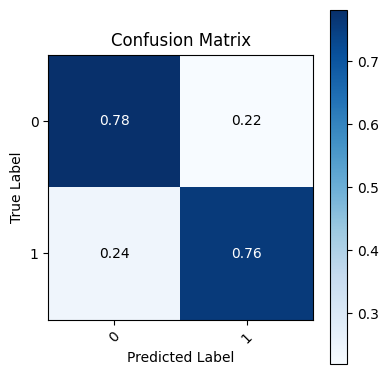

Epoch 1/10 - Average Training Loss: 0.7163


Epoch 2/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

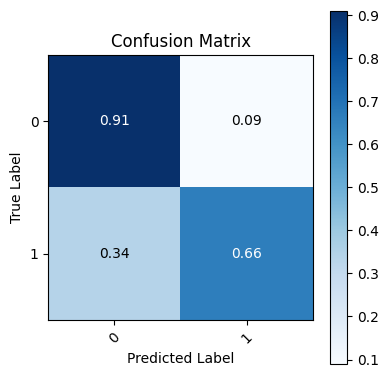

Epoch 2/10 - Average Training Loss: 0.6296


Epoch 3/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 3/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

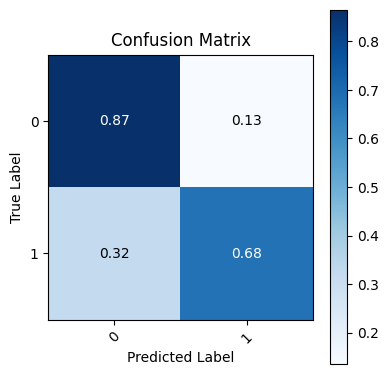

Epoch 3/10 - Average Training Loss: 0.6071


Epoch 4/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 4/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

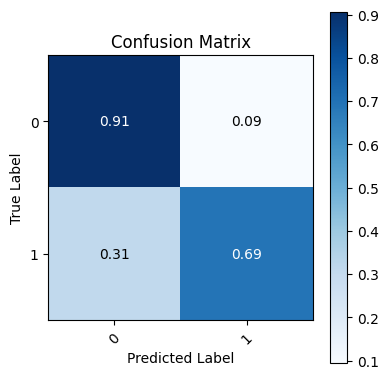

Epoch 4/10 - Average Training Loss: 0.5920


Epoch 5/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 5/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

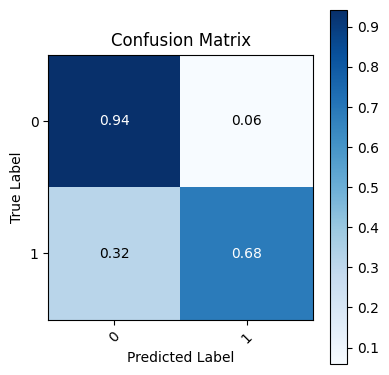

Epoch 5/10 - Average Training Loss: 0.5901


Epoch 6/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 6/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

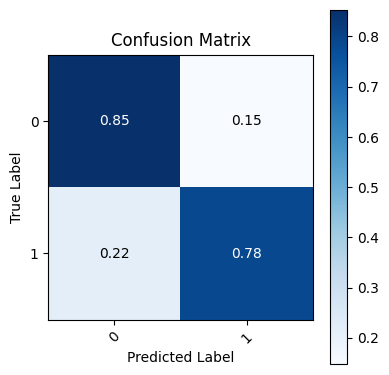

Epoch 6/10 - Average Training Loss: 0.5839


Epoch 7/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 7/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

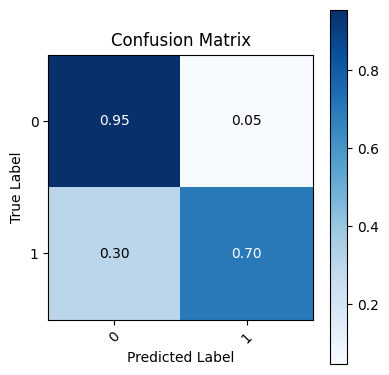

Epoch 7/10 - Average Training Loss: 0.5845


Epoch 8/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 8/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

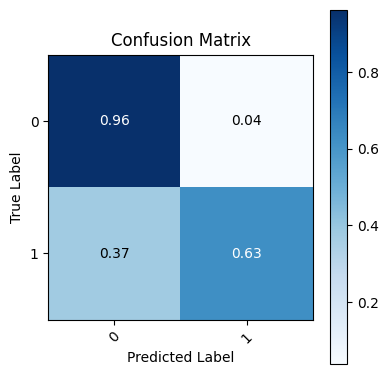

Epoch 8/10 - Average Training Loss: 0.5785


Epoch 9/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 9/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

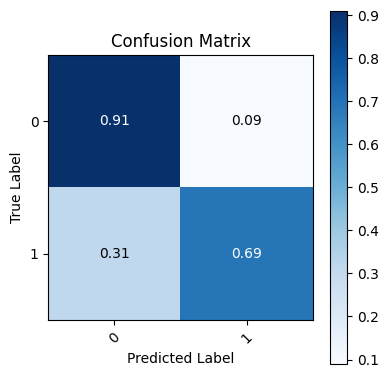

Epoch 9/10 - Average Training Loss: 0.5736


Epoch 10/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 10/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

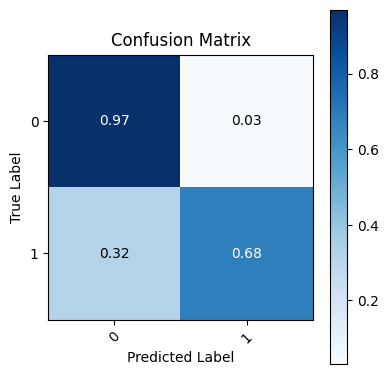

Epoch 10/10 - Average Training Loss: 0.5775


In [5]:
NUM_EPOCHS = 10
loss = nn.BCEWithLogitsLoss()  # We can also use DiceLoss() from MONAI for segmentation tasks
loss = DiceLoss(sigmoid=True)  # DiceLoss with sigmoid activation
optimizer = torch.optim.Adam(unet.parameters(), lr=1e-3, weight_decay=1e-5)

for epoch in range(NUM_EPOCHS):
    unet.train()
    train_loss = 0.0
    for images, masks in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        images = images.cuda()
        masks = masks.cuda()
        optimizer.zero_grad()
        outputs = unet(images)
        loss_value = loss(outputs.squeeze(1), masks.float())
        loss_value.backward()
        optimizer.step()
        train_loss += loss_value.item()
    val_pred, val_gt = [], []
    unet.eval()
    
    for images, masks in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Validation"):
        images = images.cuda()
        with torch.no_grad():
            outputs = unet(images)
            outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
            outputs = (outputs > 0.5).long()  # Convert to binary mask
            val_pred.append(outputs.cpu())
            val_gt.append(masks)
    compute_and_plot_confusion_matrix(torch.cat(val_pred, dim=0), torch.cat(val_gt, dim=0), num_classes=2)
    avg_train_loss = train_loss / len(train_dataloader)
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Average Training Loss: {avg_train_loss:.4f}")

In [8]:
import wandb
from torchmetrics.segmentation import DiceScore
from torchmetrics.classification import Recall, Precision
from torchmetrics import MetricCollection
from torchmetrics import ConfusionMatrix
import segmentation_models_pytorch as smp

model = smp.Unet(encoder_name="resnet34", encoder_weights="imagenet", in_channels=1, classes=1).cuda()

metrics = MetricCollection({
    "dice_score": DiceScore(num_classes=2),
    "precision": Precision(num_classes=2, task='binary'),
    "recall": Recall(num_classes=2, task='binary')
})

conf_matrix = ConfusionMatrix(num_classes=2, task='binary')
wandb.init(project="sys800_segmentation", name="unet_training")
for epoch in range(NUM_EPOCHS):
    metrics.reset()
    conf_matrix.reset()
    unet.train()
    train_loss = 0.0
    for images, masks in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Training"):
        images = images.cuda()
        masks = masks.cuda()
        optimizer.zero_grad()
        outputs = unet(images)
        loss_value = loss(outputs.squeeze(1), masks.float())
        loss_value.backward()
        optimizer.step()
        train_loss += loss_value.item()
    val_pred, val_gt = [], []
    unet.eval()
    wandb.log({"train_loss": train_loss / len(train_dataloader)}, step=epoch)
    for images, masks in tqdm(val_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} - Validation"):
        images = images.cuda()
        with torch.no_grad():
            outputs = unet(images)
            outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
            outputs = (outputs > 0.5).long().squeeze(1)  # Convert to binary mask
            metrics.update(outputs.cpu(), masks.cpu())
            conf_matrix.update(outputs.cpu(), masks.cpu())
            
            val_pred.append(outputs.cpu())
            val_gt.append(masks)
    avg_train_loss = train_loss / len(train_dataloader)
    metric_dict = metrics.compute()
    # Log metrics to Weights & Biases
    preds_flat = torch.cat(val_pred, dim=0).long().cpu().numpy().reshape(-1).tolist()
    gt_flat = torch.cat(val_gt, dim=0).long().cpu().numpy().reshape(-1).tolist()
    wandb.log({"train_loss": avg_train_loss, **metric_dict, "conf_matrix": wandb.plot.confusion_matrix( 
            preds=preds_flat, y_true=gt_flat,
            class_names=["BG", "VS"])})
    
    
    
    
    

c:\Users\cleme\miniconda3\envs\torch\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: clement-playout (liv4d-polytechnique). Use `wandb login --relogin` to force relogin


Epoch 1/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 1/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 2/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 2/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

...

Epoch 8/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 9/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 9/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 10/10 - Training:   0%|          | 0/125 [00:00<?, ?it/s]

Epoch 10/10 - Validation:   0%|          | 0/25 [00:00<?, ?it/s]

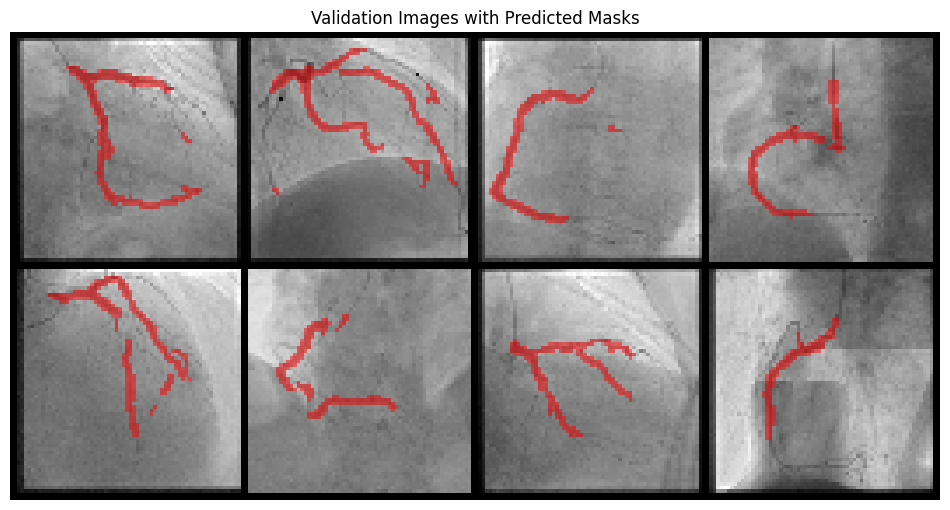

In [18]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from torchvision.utils import make_grid, draw_segmentation_masks

# Take a batch of validation images and their corresponding predictions
images, masks = next(iter(val_dataloader))

images = images.cuda()
with torch.no_grad():
    outputs = unet(images)
    outputs = torch.sigmoid(outputs)  # Apply sigmoid to get probabilities
    outputs = (outputs > 0.5).float()  # Convert to binary mask

# Make image grid for visualization
image_grid = make_grid(images.cpu(), nrow=4, normalize=True)
# Draw segmentation masks on the image grid
mask_grid = make_grid(outputs.cpu(), nrow=4, normalize=True).mean(0)
# Combine image and mask grids for visualization
cmap = ListedColormap(["#ffff0000", 'red'])  # Define a colormap for the masks
plt.figure(figsize=(12, 12))
plt.imshow(image_grid.permute(1, 2, 0))
plt.imshow(mask_grid, alpha=0.5, cmap=cmap, vmin=0, vmax=1)  # Overlay masks with some transparency
plt.axis('off')
plt.title("Validation Images with Predicted Masks")
plt.show()